In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

In [3]:
file = pd.read_csv("D:\datas\pima\diabetes.csv")
train = file.copy()
train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


查看每个变量的分布 及其与标签之间的关系

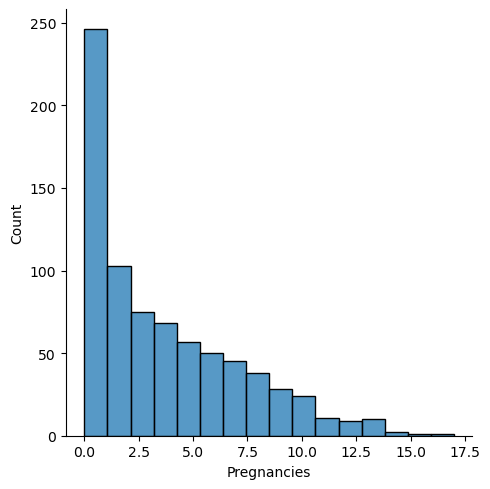

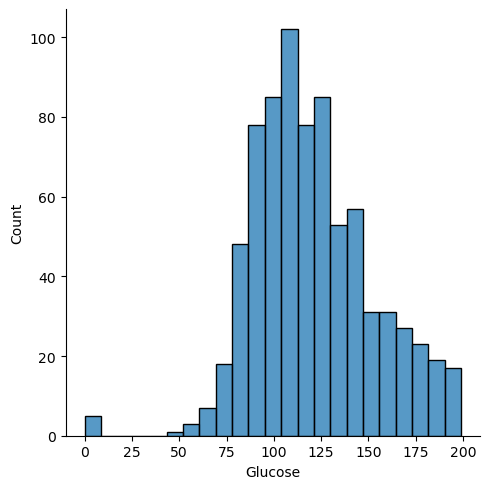

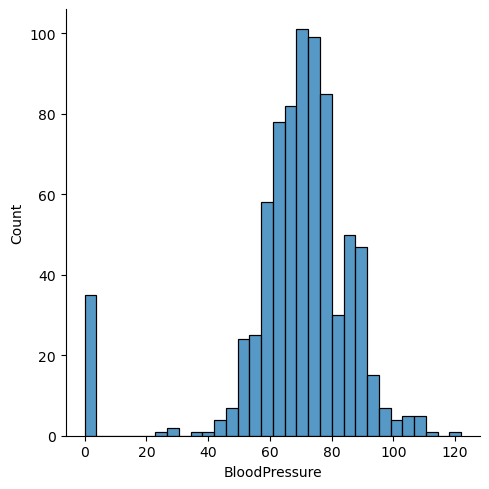

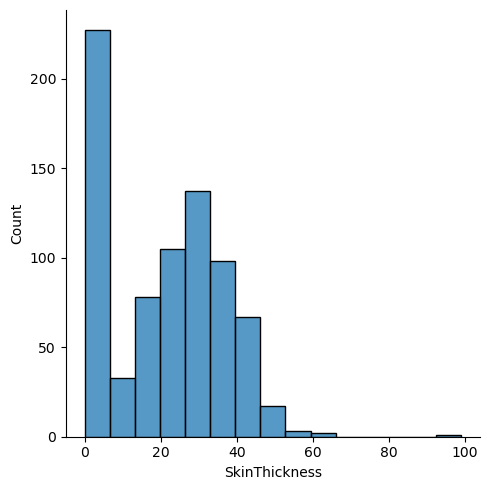

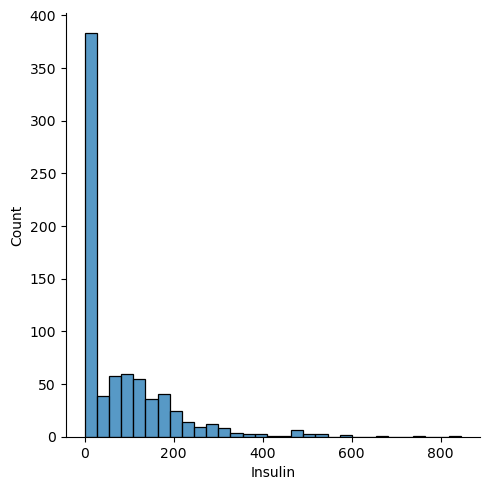

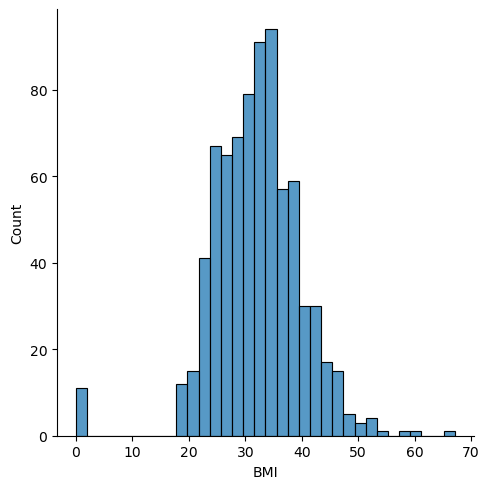

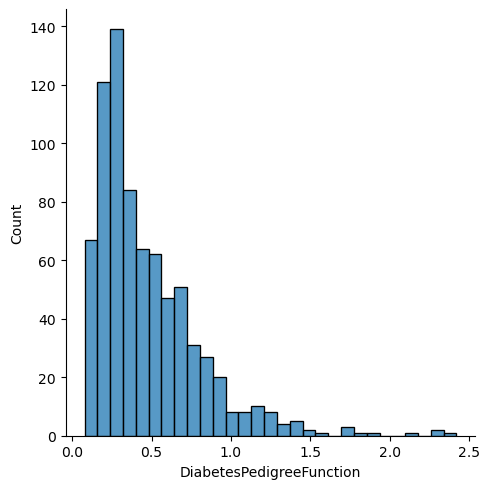

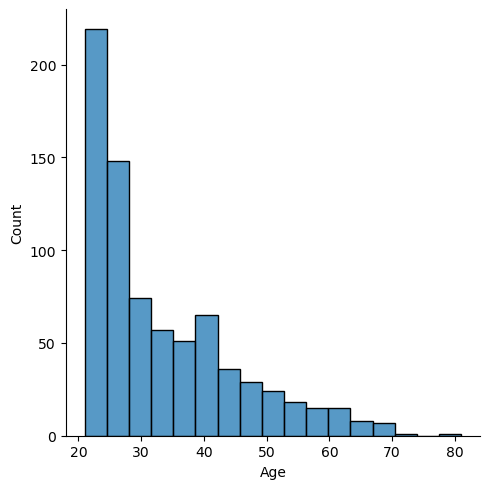

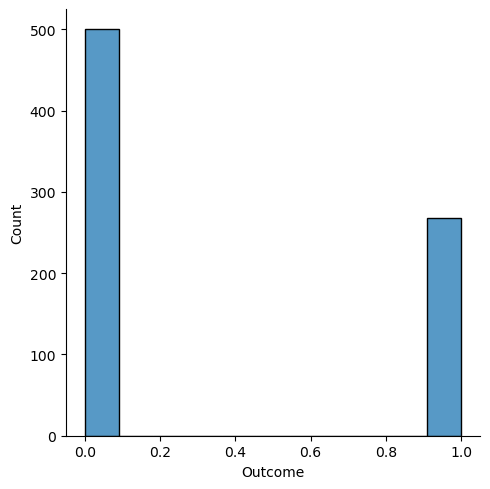

In [4]:
# 单变量
for feature in train.columns:
    sns.displot(train[feature],kde=False)
    plt.show()


<Axes: xlabel='Glucose', ylabel='count'>

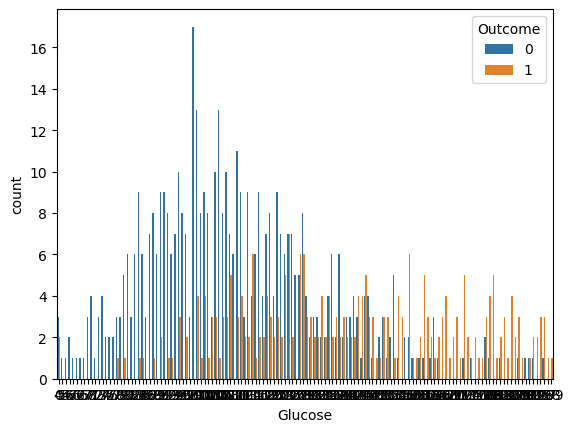

In [5]:
# 怀孕次数
sns.countplot(x='Glucose',hue='Outcome',data=train)

怀孕次数越高，发病率越高

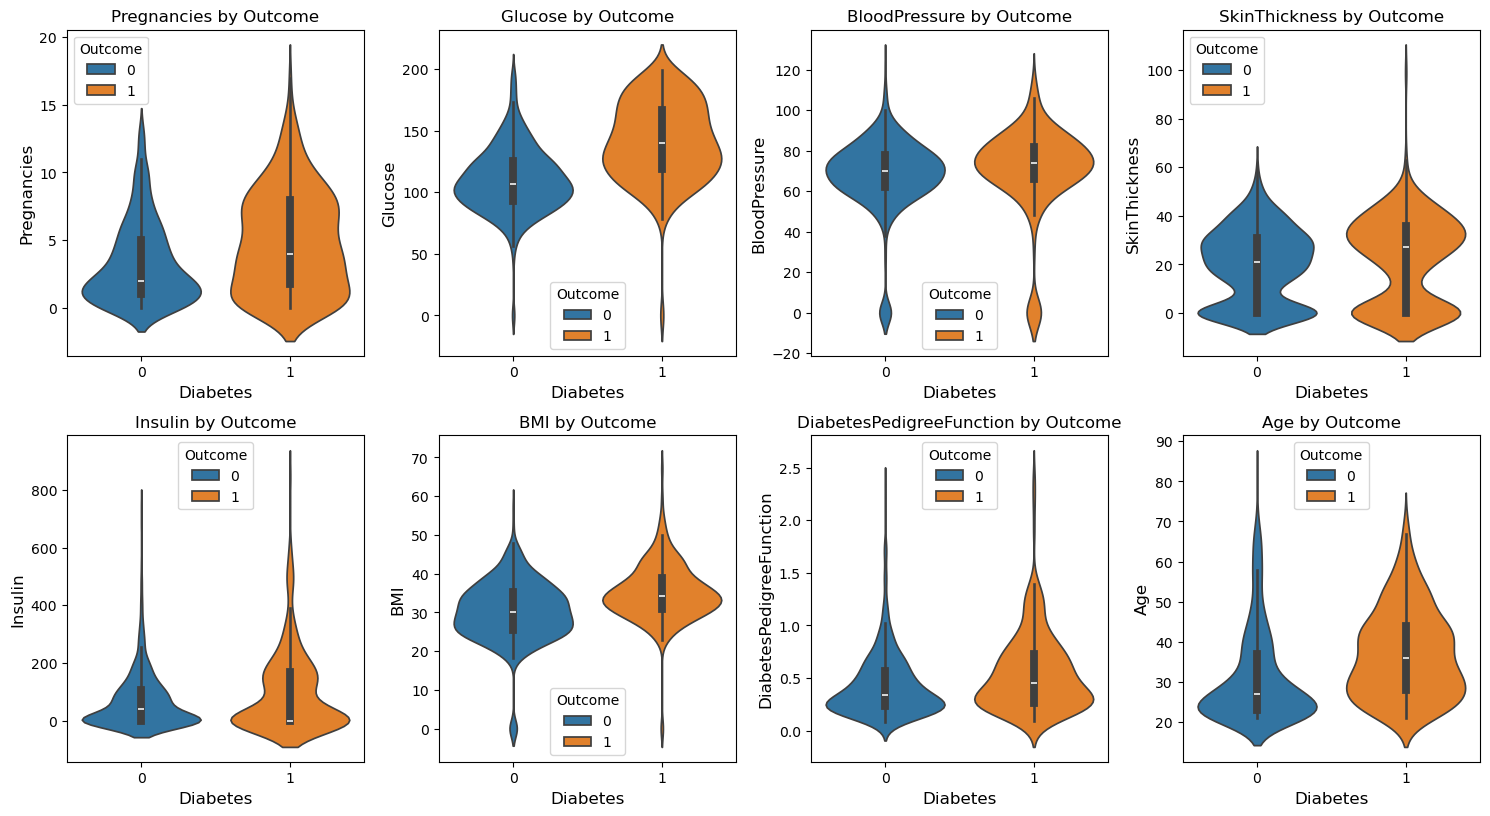

In [6]:

plt.figure(figsize=(15, 20))

for i, feature in enumerate(train.columns):
    if feature == 'Outcome':
        continue
        
    plt.subplot(5, 4, i+1)  
    sns.violinplot(x='Outcome', y=feature, data=train, hue='Outcome')
    plt.xlabel('Diabetes', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.title(f'{feature} by Outcome')


plt.tight_layout()
plt.show()

<Axes: xlabel='BMI'>

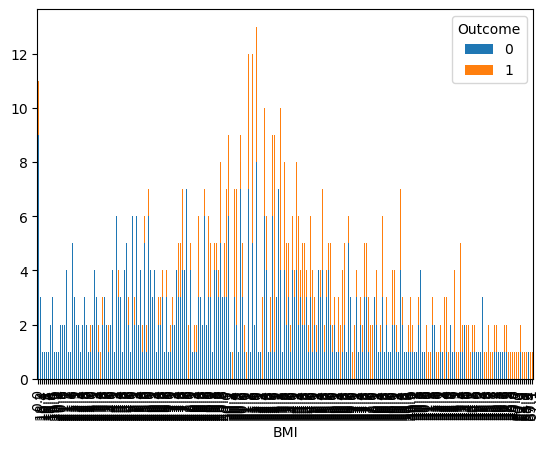

In [7]:
BMIDF = train.groupby(['BMI','Outcome'])['BMI'].count().unstack('Outcome').fillna(0)
BMIDF[[0,1]].plot(kind='bar',stacked = True)

1.血糖越高，发病率越高
2.年龄和得病成正比
3.三头肌厚度正相关
4.越胖与得病正相关
5.

<Axes: xlabel='DiabetesPedigreeFunction'>

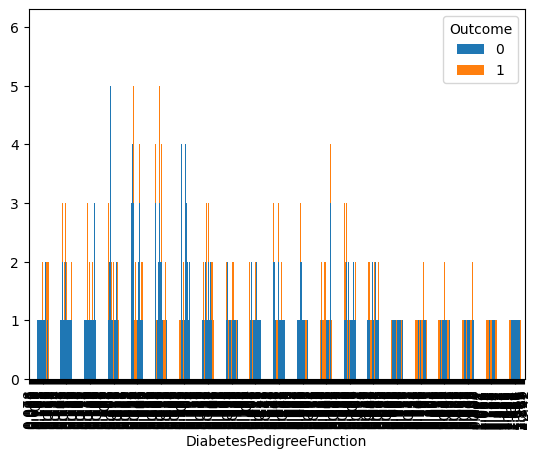

In [8]:
DF = train.groupby(['DiabetesPedigreeFunction','Outcome'])['DiabetesPedigreeFunction'].count().unstack('Outcome').fillna(0)
DF[[0,1]].plot(kind='bar',stacked = True)


<Axes: xlabel='Age'>

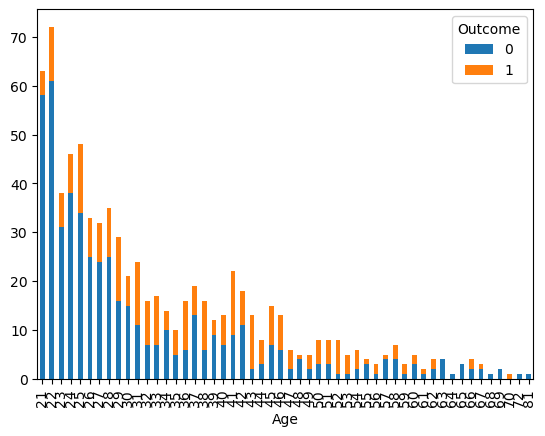

In [9]:
DF = train.groupby(['Age','Outcome'])['Age'].count().unstack('Outcome').fillna(0)
DF[[0,1]].plot(kind='bar',stacked = True)

<Axes: >

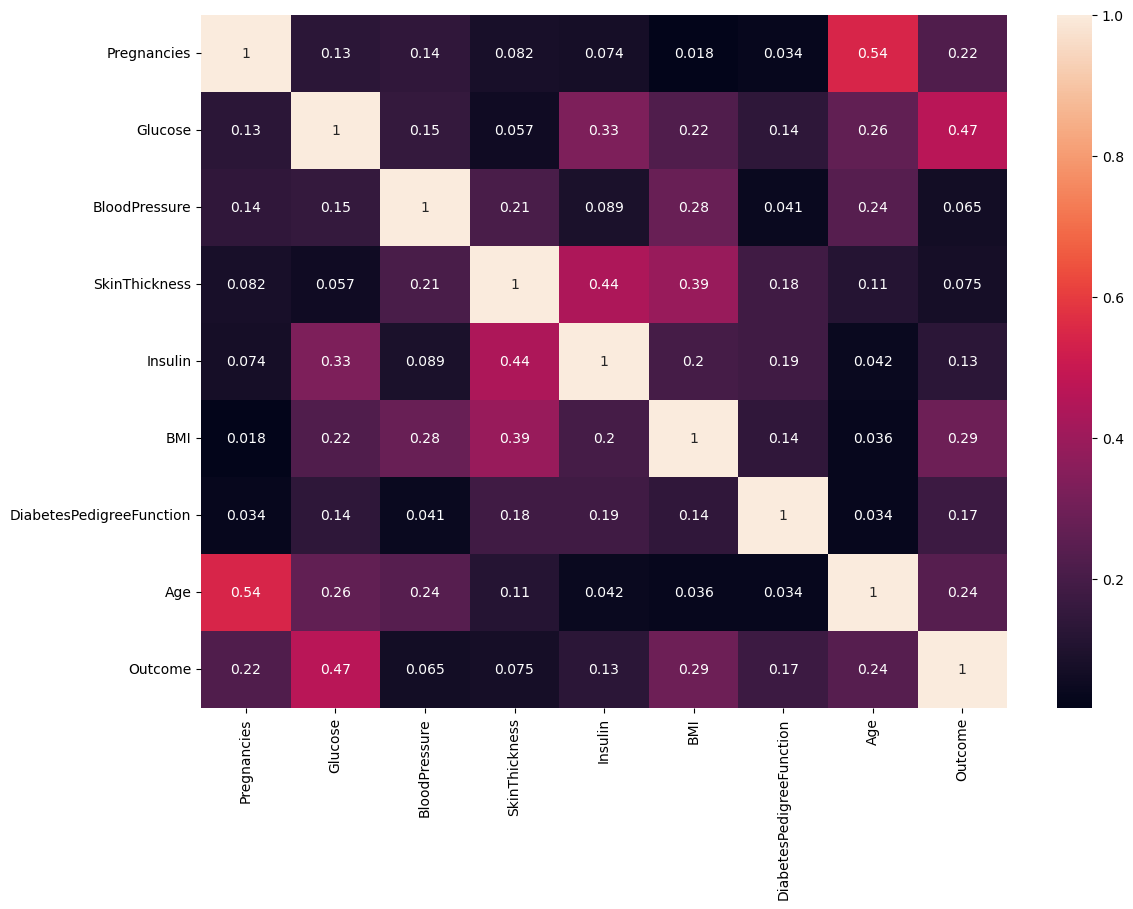

In [10]:
data_corr = train.corr().abs()
plt.subplots(figsize=(13,9))
sns.heatmap(data_corr,annot=True)